In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer,MissingIndicator

In [ ]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [ ]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train['Age_imputed']=X_train['Age']
X_test['Age_imputed']=X_test['Age']

In [ ]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_2891/500413249.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()]=X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_2891/500413249.py:2

In [ ]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,30.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


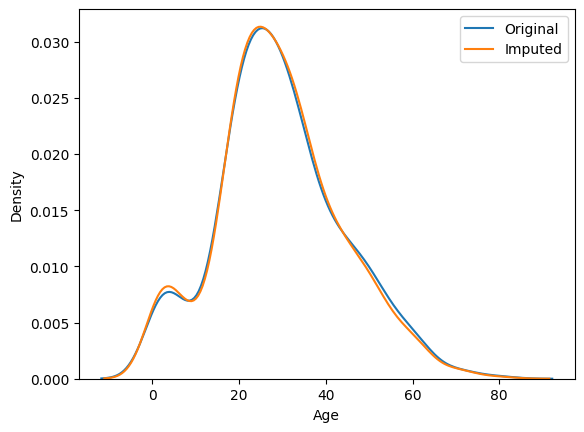

In [ ]:
sns.kdeplot(X_train['Age'],label='Original')
sns.kdeplot(X_train['Age_imputed'],label='Imputed')
plt.legend()

<Axes: >

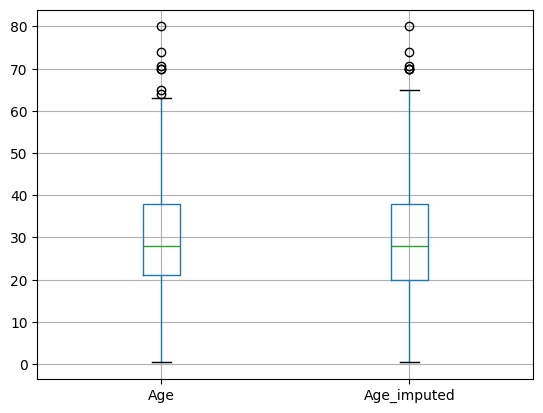

In [ ]:
X_train[['Age','Age_imputed']].boxplot()

In [ ]:
df=pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [ ]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [ ]:
X=df
y=df['SalePrice']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train['GarageQual_imputed']=X_train['GarageQual']
X_test['GarageQual_imputed']=X_test['GarageQual']
X_train['FireplaceQu_imputed']=X_train['FireplaceQu']
X_test['FireplaceQu_imputed']=X_test['FireplaceQu']

In [ ]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
153,Gd,TA,235000,TA,Gd
194,NaN,TA,127000,TA,NaN
1193,NaN,TA,165000,TA,NaN
386,NaN,NaN,81000,NaN,NaN
166,Gd,TA,190000,TA,Gd


In [ ]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()]=X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()]=X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()]=X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()]=X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_2891/2459951313.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()]=X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tmp/

In [ ]:
temp=pd.concat([X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),
                X_train['FireplaceQu_imputed'].value_counts()/len(X_train)],axis=1)
temp.columns=['Original','Imputed']
temp

,Original,Imputed
Gd,0.491143,0.488870
TA,0.405797,0.409247
Fa,0.043478,0.042808
Ex,0.033816,0.035103
Po,0.025765,0.023973


In [ ]:
temp=pd.concat([X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
                X_train['GarageQual_imputed'].value_counts()/len(X_train)],axis=1)
temp.columns=['Original','Imputed']

In [ ]:
temp

,Original,Imputed
TA,0.951087,0.952055
Fa,0.032609,0.032534
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


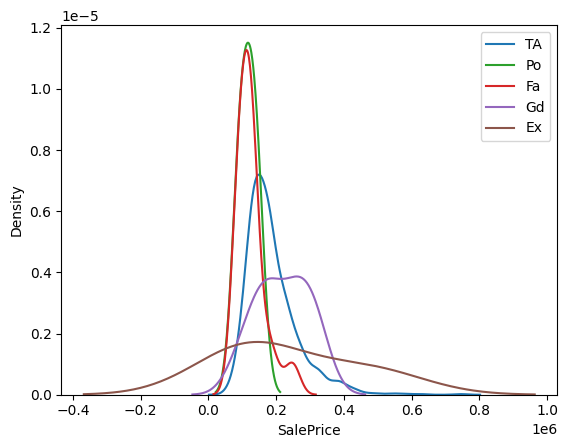

In [ ]:
for category in X_train['GarageQual'].unique():
    sns.kdeplot(X_train[X_train['GarageQual']==category]['SalePrice'],label=category)
    plt.legend()

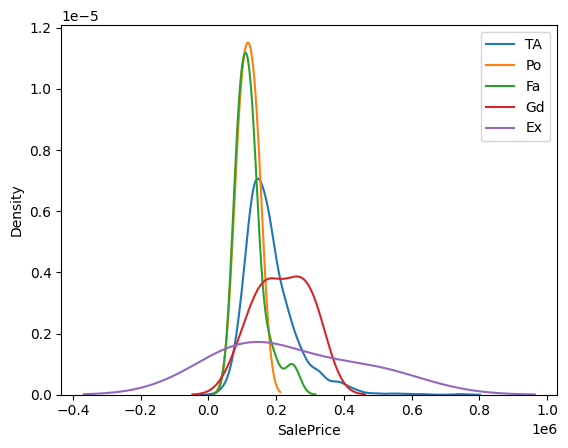

In [ ]:
for category in X_train['GarageQual_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['GarageQual_imputed']==category]['SalePrice'],label=category)
    plt.legend()

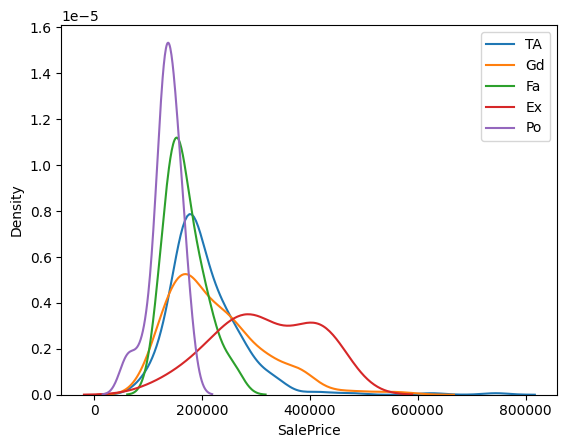

In [ ]:
for category in X_train['FireplaceQu'].dropna().unique():
  sns.kdeplot(X_train[X_train['FireplaceQu']==category]['SalePrice'],label=category)
  plt.legend()

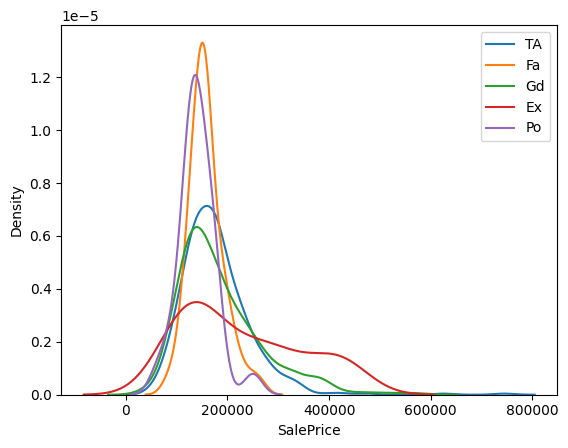

In [ ]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
  sns.kdeplot(X_train[X_train['FireplaceQu_imputed']==category]['SalePrice'],label=category)
  plt.legend()

In [ ]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
si=SimpleImputer()

In [ ]:
X_train_trf=si.fit_transform(X_train)
X_test_trf=si.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(X_train_trf,Y_train)
Y_pred=clf.predict(X_test_trf)
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_pred)

0.6480446927374302

In [ ]:
mi= MissingIndicator()

In [ ]:
mi.fit(X_train)

MissingIndicator()

In [ ]:
X_train_missing=mi.transform(X_train)

In [ ]:
X_test_missing=mi.transform(X_test)

In [ ]:
X_train['Age_NA']=X_train_missing
X_test['Age_NA']=X_test_missing

In [ ]:
X_train_trf2=si.fit_transform(X_train)
X_test_trf2=si.transform(X_test)
clf.fit(X_train_trf2,Y_train)
Y_pred=clf.predict(X_test_trf2)
accuracy_score(Y_test,Y_pred)

0.6368715083798883

In [ ]:
si=SimpleImputer(add_indicator=True)
X_train=si.fit_transform(X_train)
X_test=si.transform(X_test)
clf.fit(X_train,Y_train)
Y_pred=clf.predict(X_test)
accuracy_score(Y_test,Y_pred)

0.6368715083798883